#### ***Тут мы будем пытаться предсказать совершение покупки пользователем во время его сессии на сайте некоторого интернет-магазина.***

In [1]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import metrics #метрики
from sklearn import model_selection #методы разделения и валидации
from sklearn import ensemble #ансамбли
from sklearn import tree
from sklearn.model_selection import cross_validate

plt.style.use('seaborn-v0_8') #стиль отрисовки seaborn
%matplotlib inline

In [2]:
shoppers_data = pd.read_csv('data/shop.csv')
shoppers_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# Посмотрим на размер таблицы
print(shoppers_data.shape)

(12330, 18)


In [4]:
#Проверяем на наличие пропусков
shoppers_data.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [5]:
#Теперь закодируем категориальные признаки с помощью простого горячего кодирования
dummy_data = pd.get_dummies(shoppers_data)
dummy_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True


Sessions without purchase: 84.53%
Sessions with purchase: 15.47%


C:\Users\Кирилл\AppData\Local\Temp\ipykernel_19712\698094994.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=dummy_data, palette='viridis')


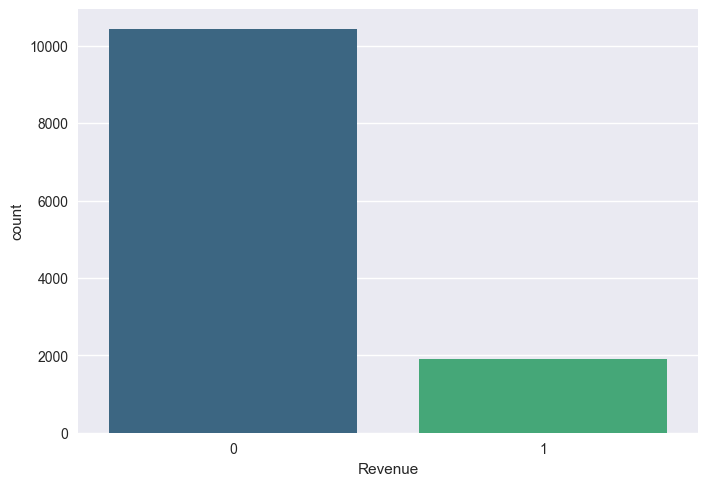

In [6]:
#Посмотрим на соотношение классов данных
dummy_data['Revenue'] = dummy_data['Revenue'].astype(int)

sns.countplot(x='Revenue', data=dummy_data, palette='viridis')
class_percent = dummy_data['Revenue'].value_counts(normalize=True) * 100
print('Sessions without purchase: {:.2f}%'.format(class_percent[0]))
print('Sessions with purchase: {:.2f}%'.format(class_percent[1]))

Выборка не сбалансированна

In [7]:
#По традиции разделим набор данных на матрицу наблюдений X и вектор ответов y:
X, y = dummy_data.drop('Revenue', axis=1), dummy_data['Revenue']

Разделим выборку на тренировочную и тестовую в соотношении 80/20. Используем разбиение, стратифицированное по целевому признаку. В качестве значения параметра random_state возьмем число 42.

In [8]:
X_train, X_valid, y_train, y_valid = model_selection.train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
print('Train\n', y_train.value_counts(normalize = True), sep='')
print('Valid\n', y_valid.value_counts(normalize=True), sep='')

Train
Revenue
0    0.845296
1    0.154704
Name: proportion, dtype: float64
Valid
Revenue
0    0.845093
1    0.154907
Name: proportion, dtype: float64


In [9]:
print(len(X_train))
print(len(X_valid))

9864
2466


Задание 6.3

Создайте модель случайного леса. В качестве значения параметра random_state возьмите число 42. Остальные параметры оставьте по умолчанию.

Оцените качество такой модели с помощью кросс-валидации по пяти фолдам. Так как классы несбалансированы, используйте кросс-валидатор StratifiedKFold (перемешивать выборку не нужно).

Для проведения кросс-валидации используйте функцию cross_validate(). Набор данных (параметры X, y) — тренировочная выборка (X_train, y_train). Метрика — F1-score.

Чему равно среднее значение метрики F1 на тренировочных и валидационных фолдах? Ответ округлите до двух знаков после точки-разделителя.

In [10]:
#Создаем модель
forest = ensemble.RandomForestClassifier(random_state=42)

forest.fit(X_train, y_train)
y_train_pred = forest.predict(X_train)
y_valid_pred = forest.predict(X_valid)

skf = model_selection.StratifiedKFold(n_splits=5, shuffle = False)

cv_metrics = model_selection.cross_validate(
    estimator=forest,
    X=X,
    y=y,
    cv=skf,
    scoring='f1',
    return_train_score=True
)

print(f"Mean train F1: {cv_metrics['train_score'].mean():.2f}")
print(f"Mean valid F1: {cv_metrics['test_score'].mean():.2f}")

Mean train F1: 1.00
Mean valid F1: 0.63


In [11]:
#Создаём список из моделей
models = [
    ensemble.RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=5,
    random_state=42,
    max_depth=5
    ),

    ensemble.RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=5,
    random_state=42,
    max_depth=7
    ),
    ensemble.RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=5,
    random_state=42,
    max_depth=12
    )
]

In [12]:
def plot_learning_curve(model, X, y, cv, scoring="f1", ax=None, title=""):
    # Вычисляем координаты для построения кривой обучения
    train_sizes, train_scores, valid_scores = model_selection.learning_curve(
        estimator=model,  # модель
        X=X,  # матрица наблюдений X
        y=y,  # вектор ответов y
        cv=cv,  # кросс-валидатор
        scoring=scoring,  # метрика
    )
    # Вычисляем среднее значение по фолдам для каждого набора данных
    train_scores_mean = np.mean(train_scores, axis=1)
    valid_scores_mean = np.mean(valid_scores, axis=1)
    # Если координатной плоскости не было передано, создаём новую
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))  # фигура + координатная плоскость
    # Строим кривую обучения по метрикам на тренировочных фолдах
    ax.plot(train_sizes, train_scores_mean, label="Train")
    # Строим кривую обучения по метрикам на валидационных фолдах
    ax.plot(train_sizes, valid_scores_mean, label="Valid")
    # Даём название графику и подписи осям
    ax.set_title("Learning curve: {}".format(title))
    ax.set_xlabel("Train data size")
    ax.set_ylabel("Score")
    # Устанавливаем отметки по оси абсцисс
    ax.xaxis.set_ticks(train_sizes)
    # Устанавливаем диапазон оси ординат
    ax.set_ylim(0, 1)
    # Отображаем легенду
    ax.legend()

c:\Users\Кирилл\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Кирилл\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Кирилл\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Кирилл\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 409, in _score
    y_pred = method_calle

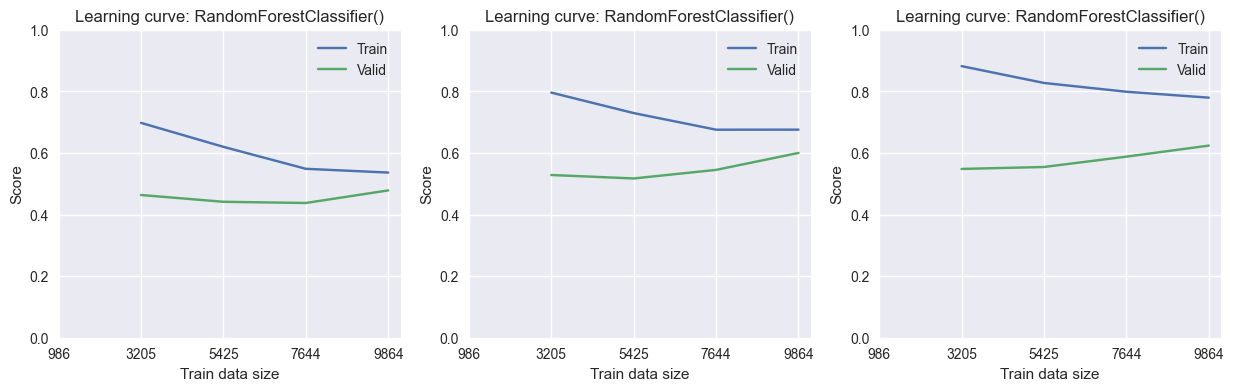

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4)) #фигура + 3 координатных плоскости
#Создаем цикл по списку моделей и индексам этого списка
for i, model in enumerate(models): #i-текущий индекс, model - текущая модель
    plot_learning_curve(
        model, X, y, 
        skf, 
        ax=axes[i], 
        title=model.__class__.__name__ + '()'
)

Оптимальная глубина случайного леса показана на 2 графике и равна 7

In [15]:
rf = ensemble.RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=5,
    random_state=42,
    max_depth=7
    )

rf.fit(X_train, y_train)
y_train_rf = rf.predict(X_train)
y_valid_rf = rf.predict(X_valid)

print(metrics.classification_report(y_valid, y_valid_rf))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      2084
           1       0.79      0.49      0.60       382

    accuracy                           0.90      2466
   macro avg       0.85      0.73      0.77      2466
weighted avg       0.89      0.90      0.89      2466



Модель хорошо определяет всех посетителей, которые завершат сессию без покупки, а вот качество распознавания пользователей, совершивших покупку, значительно ниже.

Попробуем повысить качество распознавания посетителей, совершивших покупку. Используем метод подбора порога вероятности с помощью PR-кривой.

Порог вероятности будем подбирать с помощью кросс-валидации.

Сделайте предсказание вероятностей принадлежности к пользователям, которые совершат покупку, на кросс-валидации на пяти фолдах. Используйте метод cross_val_predict().

Для кросс-валидации используйте случайный лес с подобранной в задании 6.5 оптимальной максимальной глубиной деревьев, набор данных (параметры X, y) — тренировочная выборка (X_train, y_train).

Постройте PR-кривую и отметьте на ней точку, в которой наблюдается максимум метрики F1 для посетителей, которые совершат покупку. Определите порог вероятности, соответствующий этой точке.

In [20]:
model_forest = ensemble.RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=5,
    random_state=42,
    max_depth=7
    )

#Обучаем модель
model_forest.fit(X_train, y_train)
#Создаем кросс-валидатор
skf = model_selection.StratifiedKFold(n_splits=5)
#Делаем предсказание вероятностей на кросс-валидации
y_cv_proba_pred = model_selection.cross_val_predict(model_forest, X_train, y_train, cv=skf, method='predict_proba')
#Выделяем столбец с вероятностями для класса 1
y_cv_proba_pred = y_cv_proba_pred[:,1]

Best threshold = 0.36, F1-Score = 0.69
Best threshold = 0.36, F1-Score = 0.69


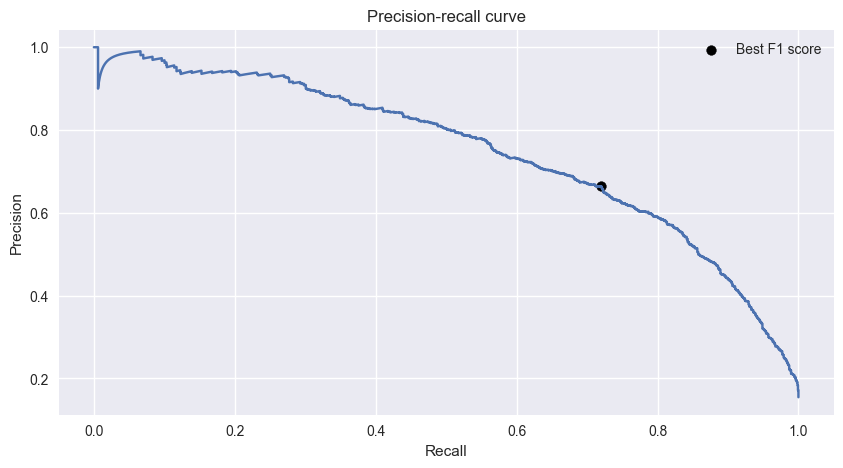

In [22]:
#Вычисляем координаты PR-кривой
precision, recall, thresholds = metrics.precision_recall_curve(y_train, y_cv_proba_pred)
#Вычисляем F1-score при различных threshold
f1_scores = (2 * precision * recall) / (precision + recall)
#Определяем индекс максимума F1
idx = np.argmax(f1_scores)
print('Best threshold = {:.2f}, F1-Score = {:.2f}'.format(thresholds[idx], f1_scores[idx]))

#Вычисляем координаты PR-кривой
precision, recall, thresholds = metrics.precision_recall_curve(y_train, y_cv_proba_pred)
#Вычисляем F1-score при различных threshold
f1_scores = (2 * precision * recall) / (precision + recall)
#Определяем индекс максимума F1
idx = np.argmax(f1_scores)
print('Best threshold = {:.2f}, F1-Score = {:.2f}'.format(thresholds[idx], f1_scores[idx]))

#Строим PR-кривую
fig, ax = plt.subplots(figsize=(10, 5)) #фигура + координатная плоскость
#Строим линейный график зависимости precision от recall
ax.plot(recall, precision)
#Отмечаем точку максимума F1
ax.scatter(recall[idx], precision[idx], marker='o', color='black', label='Best F1 score')
#Даём название графику и подписи осям
ax.set_title('Precision-recall curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
#Отображаем легенду
ax.legend()

In [23]:
#Задаем оптимальный порог вероятностей
opt_thresholds = 0.36
y_valid_proba_pred = model_forest.predict_proba(X_valid)[:,1]
y_valid_pred = (y_valid_proba_pred > opt_thresholds).astype('int')
#Считаем метрики
print(metrics.classification_report(y_valid, y_valid_pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      2084
           1       0.66      0.69      0.67       382

    accuracy                           0.90      2466
   macro avg       0.80      0.81      0.81      2466
weighted avg       0.90      0.90      0.90      2466



Благодаря подбору порога вероятности удалось повысить охват (recall) посетителей, которые совершат покупку, за счёт чего выросло значение F-score.